# Chern insulator: the Haldane model
The Haldane model adds a complex second-neighbor hopping to the honeycomb lattice,
$$ H = \sum_{\langle ij \rangle} c^\dagger_i c_j  + i t_H \sum_{\langle \langle ij \rangle \rangle} \nu_{ij} c^\dagger_i c_j $$
where $\nu_{ij}=\pm 1$ depending on the hopping direction. Unlike the sublattice-imbalance mass from the bands notebook, this term breaks time-reversal symmetry instead of inversion symmetry, and the resulting gapped phase is topologically nontrivial: it carries a quantized Chern number $C\neq 0$ and hosts protected chiral edge states (a Chern insulator), with no net magnetic field required.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Create the honeycomb lattice with Haldane coupling

In [2]:
g = geometry.honeycomb_lattice() # create the geometry
h = g.get_hamiltonian() # create hamiltonian of the system
h.add_haldane(0.1) # Haldane coupling

### Diagonalize the Bloch Hamiltonian and compute the Berry curvature
$$ H |\Psi_k \rangle = \epsilon_k |\Psi_k\rangle,\qquad \Omega(\mathbf k) = \partial_{k_x} A_y - \partial_{k_y} A_x $$
of the occupied band, and its integral over the Brillouin zone, the Chern number
$$ C = \frac{1}{2\pi}\int_{BZ} \Omega(\mathbf k)\, d^2k $$

In [3]:
(k,e) = h.get_bands() # get the bandstructure
(kx,ky,omega) = h.get_berry_curvature(nk=40,write=False) # Berry curvature over the full BZ
C = h.get_chern() # get the Chern number
print(f"Chern number: {C:.3f}")

Chern number: 2.000


### Plot the Bloch band structure in the path

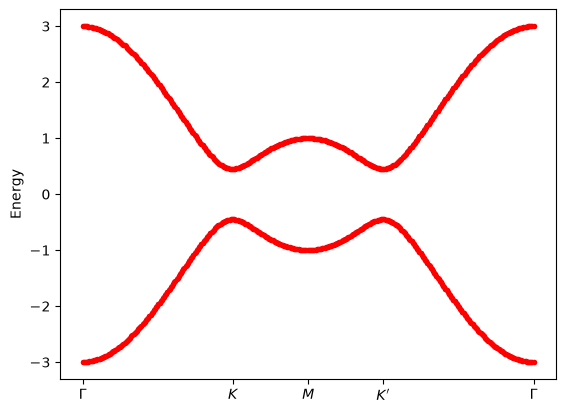

In [4]:
plt.scatter(k/max(k),e,c="red",s=8) # do a scatter plot
plt.ylabel("Energy") # set the y label
plt.xticks([0.,1/3.,0.5,2./3.,1.],["$\Gamma$","$K$","$M$","$K'$","$\Gamma$"])
plt.show() # show the plot

### Plot the Berry curvature over the Brillouin zone
The curvature is sharply peaked at the $K$ and $K'$ points — the same points where the Haldane mass opens the gap — and integrates to the quantized Chern number above.

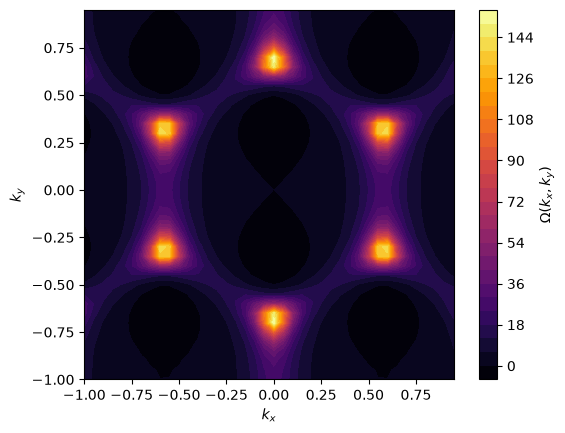

In [5]:
nk = 40
KX,KY,OMEGA = kx.reshape(nk,nk),ky.reshape(nk,nk),omega.reshape(nk,nk)
cf = plt.contourf(KX,KY,OMEGA,levels=30,cmap="inferno")
plt.colorbar(cf,label="$\Omega(k_x,k_y)$")
plt.xlabel("$k_x$") ; plt.ylabel("$k_y$")
plt.gca().set_aspect("equal")
plt.show()